# Türkçe E-Ticaret Yorumları — Yıldız Puanı Sınıflandırması (Metin Madenciliği)

Yorum metninden 1–5 yıldız tahmini yapan bir metin madenciliği çalışması.

- **Bölüm 1 — Klasik Pipeline:** Keşifsel veri analizi, metin ön işleme, TF-IDF özellik çıkarımı, Logistic Regression ile sınıflandırma ve model yorumlanabilirliği.
- **Bölüm 2 — Sızıntısız Değerlendirme ve Özellik Seçimi:** Tekrar eden kayıtların ayıklanması, yalnızca eğitim kümesine fit edilen vektörleştirme ve veri-odaklı özellik seçimi deneyi.
- **Bölüm 3 — Ek Bileşenler:** Kök bulma (stemming), Naive Bayes ile model karşılaştırması, kelime bulutu görselleştirmesi ve genel değerlendirme.

# Bölüm 1 — Klasik NLP Pipeline

## Adım 1 — Kütüphane Kurulumu
Çalışmada kullanılan görselleştirme (wordcloud, seaborn) ve makine öğrenmesi (scikit-learn) kütüphaneleri kurulur.

In [1]:
# ============================================================
# HÜCRE 1: Kütüphane Kurulumu
# ============================================================

!pip install -q wordcloud                  # Görselleştirme (kelime bulutu)
!pip install -q matplotlib seaborn         # Grafik
!pip install -q scikit-learn pandas numpy  # ML & veri

## Adım 2 — Kütüphanelerin İçe Aktarılması
Veri işleme (pandas, numpy), özellik çıkarımı ve modelleme (scikit-learn) ile görselleştirme (matplotlib, seaborn) modülleri içe aktarılır.

In [2]:
# ============================================================
# HÜCRE 2: Import'lar
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, accuracy_score)

# Kaydetme
import joblib
import warnings
warnings.filterwarnings("ignore")

print("✅ Tüm kütüphaneler yüklendi.")

✅ Tüm kütüphaneler yüklendi.


## Adım 3 — Veri Yükleme ve İlk İnceleme
Veri kümesi okunur; boyut, kolonlar ve eksik değerler incelenerek verinin genel yapısı doğrulanır.

In [3]:
# ============================================================
# HÜCRE 3: Veri Yükleme
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DOSYA_YOLU = '/content/drive/MyDrive/turkish_ecommerce_reviews/turkish_ecommerce_reviews.csv'

df = pd.read_csv(DOSYA_YOLU)

# --- İlk Bakış ---
print(f"📐 Boyut     : {df.shape}")
print(f"📋 Kolonlar  : {list(df.columns)}")
print(f"❓ Eksik veri:\n{df.isnull().sum()}")
print("\n🔍 İlk 3 satır:")
df.head(3)

Mounted at /content/drive
📐 Boyut     : (272216, 9)
📋 Kolonlar  : ['Rating (Star)', 'Review', 'review_length', 'exclamation_count', 'question_count', 'upper_ratio', 'Brand', 'Product_Name', 'URL']
❓ Eksik veri:
Rating (Star)          0
Review                 0
review_length          0
exclamation_count      0
question_count         0
upper_ratio            0
Brand                359
Product_Name           0
URL                    0
dtype: int64

🔍 İlk 3 satır:


,Rating (Star),Review,review_length,exclamation_count,question_count,upper_ratio,Brand,Product_Name,URL
0,5,3 yıldır tık demedi. :),23,0,0,0.000000,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...
1,5,3 yıldır kullanıyorum müthiş,28,0,0,0.000000,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...
2,4,ürün bugün elime geçti çok fazla inceleme fırs...,512,0,0,0.009766,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...


## Adım 4 — Keşifsel Veri Analizi (EDA)
Puan dağılımı, yorum uzunluğu ve metadata özelliklerinin puana göre değişimi görselleştirilir. Veri kümesi sınıf açısından dengesizdir (5★ ≈ %61); bu durum, sonraki adımlardaki sınıf ağırlıklandırma kararını gerektirir.

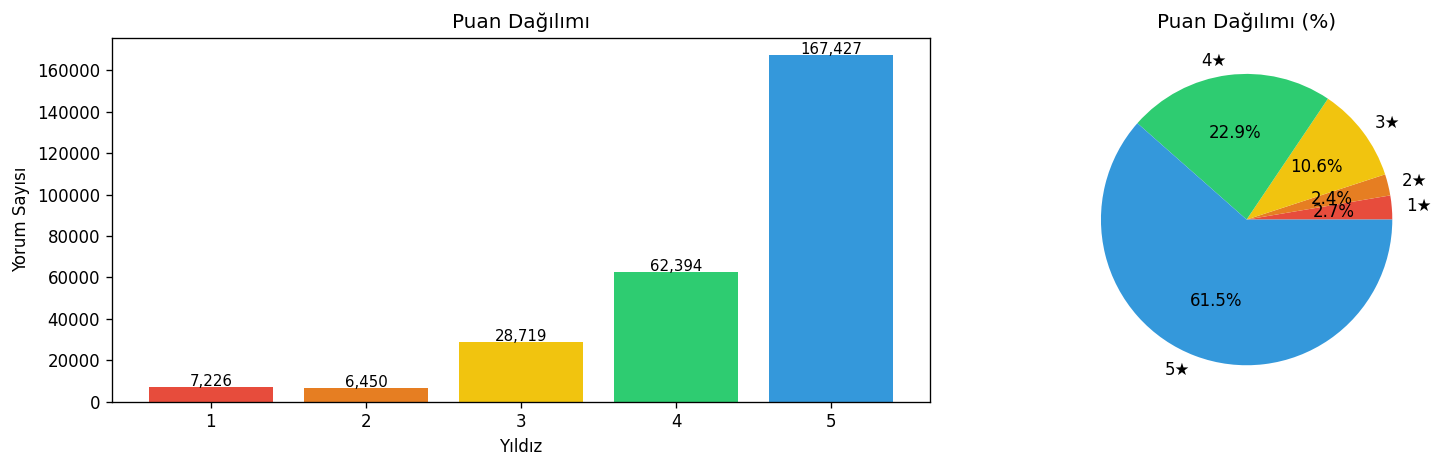

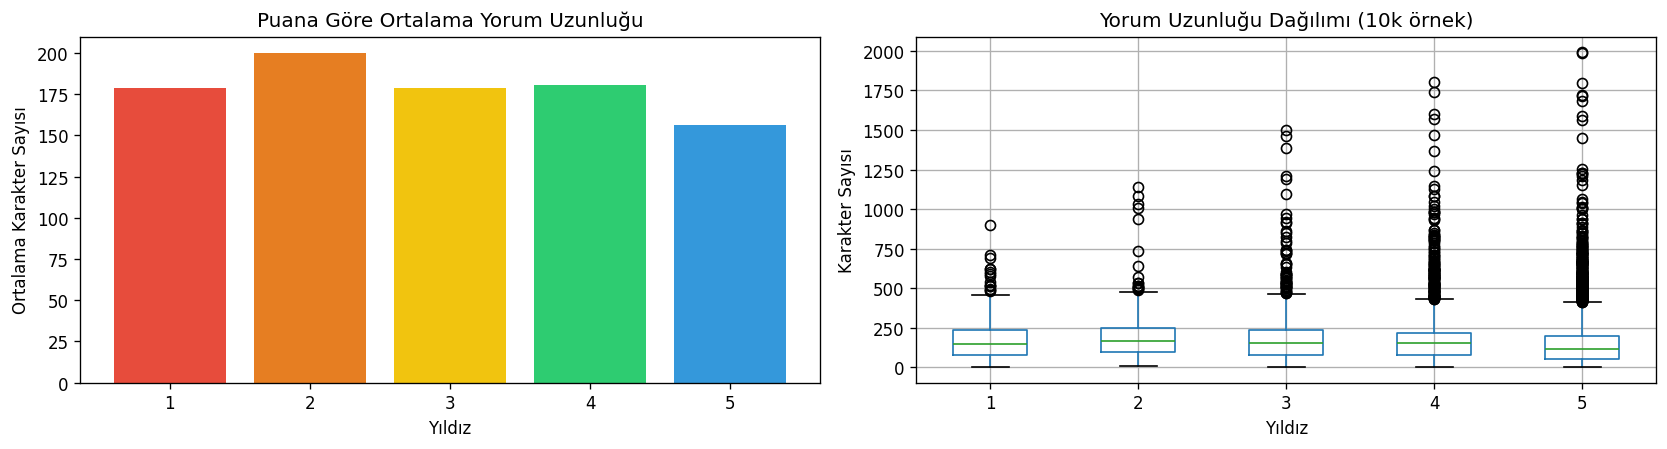

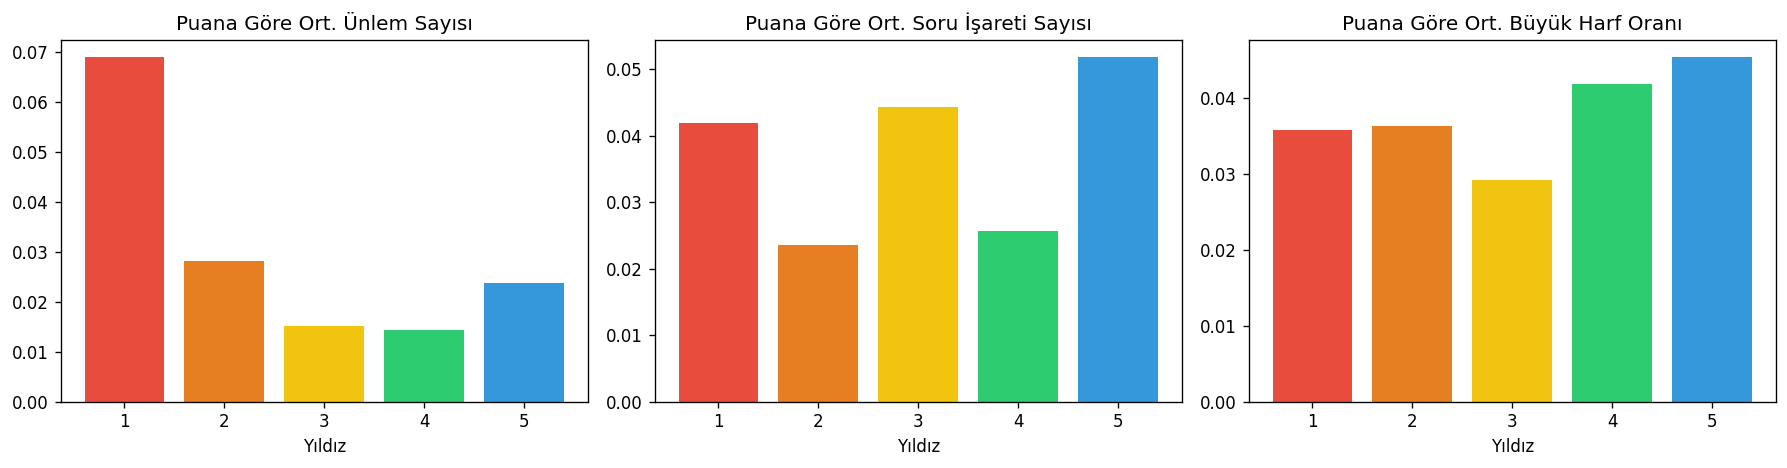

📊 Özet İstatistikler:
           count   mean    std  min   25%    50%    75%     max
rating                                                         
1         7226.0  178.7  153.0  3.0  78.0  145.0  228.0  1994.0
2         6450.0  200.0  166.5  3.0  98.0  166.0  248.0  1995.0
3        28719.0  178.6  156.7  3.0  79.0  151.0  221.0  2012.0
4        62394.0  180.6  161.8  3.0  77.0  157.0  221.0  2000.0
5       167427.0  156.3  161.9  3.0  54.0  117.0  199.0  2057.0


In [4]:
# ============================================================
# HÜCRE 4: EDA & Görselleştirme
# ============================================================

# --- Kolon isimlerini standartlaştır ---
df.rename(columns={'Rating (Star)': 'rating'}, inplace=True)

# ── 4.1 Puan Dağılımı ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Puan Dağılımı')
axes[0].set_xlabel('Yıldız')
axes[0].set_ylabel('Yorum Sayısı')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Yüzde pasta
axes[1].pie(rating_counts.values,
            labels=[f'{i}★' for i in rating_counts.index],
            autopct='%1.1f%%',
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Puan Dağılımı (%)')
plt.tight_layout()
plt.show()

# ── 4.2 Yorum Uzunluğu Analizi ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Puana göre ortalama uzunluk
avg_len = df.groupby('rating')['review_length'].mean()
axes[0].bar(avg_len.index, avg_len.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Puana Göre Ortalama Yorum Uzunluğu')
axes[0].set_xlabel('Yıldız')
axes[0].set_ylabel('Ortalama Karakter Sayısı')

# Dağılım (boxplot)
df_sample = df.sample(10000, random_state=42)  # 272k için sample al
df_sample.boxplot(column='review_length', by='rating', ax=axes[1])
axes[1].set_title('Yorum Uzunluğu Dağılımı (10k örnek)')
axes[1].set_xlabel('Yıldız')
axes[1].set_ylabel('Karakter Sayısı')
plt.suptitle('')
plt.tight_layout()
plt.show()

# ── 4.3 Metadata Özellikleri Analizi ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['exclamation_count', 'question_count', 'upper_ratio'],
    ['Ünlem Sayısı', 'Soru İşareti Sayısı', 'Büyük Harf Oranı']):
    avg = df.groupby('rating')[col].mean()
    ax.bar(avg.index, avg.values,
           color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
    ax.set_title(f'Puana Göre Ort. {title}')
    ax.set_xlabel('Yıldız')

plt.tight_layout()
plt.show()

# ── 4.4 Özet İstatistik ────────────────────────────────────
print("📊 Özet İstatistikler:")
print(df.groupby('rating')['review_length'].describe().round(1))

## Adım 5 — Kelime Frekans Analizi
Tüm yorumlardaki kelimelerin frekansları hesaplanır ve listelenir. Yüksek frekanslı kelimeler, stopword listesi için aday olarak değerlendirilir.

In [5]:
# ============================================================
# HÜCRE 5.A: Kelime Frekans İşlemleri (Stopwords Listesi İçin)
# ============================================================
from collections import Counter
import re, string

# ── Metin Temizle & Counter Oluştur ────────────────
def build_word_counter(df, text_col='Review'):
    """
    DataFrame'deki metin sütunundan kelime frekans sayacı oluşturur.
    Returns: Counter objesi
    """
    def _clean(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        return text

    print(f"⏳ '{text_col}' sütunu işleniyor...")
    all_text = ' '.join(df[text_col].apply(_clean))
    words = [w for w in all_text.split() if len(w) > 1]
    word_counter = Counter(words)
    print(f"✅ Unique kelime: {len(word_counter):,} | Toplam token: {sum(word_counter.values()):,}")
    return word_counter


# ── Counter'ı TXT'ye Kaydet ────────────────────────
def save_word_frequencies(word_counter, save_path, min_freq=1):
    """
    Kelime frekanslarını TXT dosyasına kaydeder.
    min_freq: sadece bu frekans ve üzerindeki kelimeleri yazar
    """
    filtered = [(w, f) for w, f in word_counter.most_common() if f >= min_freq]

    with open(save_path, 'w', encoding='utf-8') as file:
        file.write(f"Toplam unique kelime (min_freq={min_freq}): {len(filtered):,}\n")
        file.write(f"Toplam token sayısı: {sum(word_counter.values()):,}\n")
        file.write("=" * 40 + "\n")
        file.write(f"{'Kelime':<25} {'Frekans':>10}\n")
        file.write("=" * 40 + "\n")
        for word, freq in filtered:
            file.write(f"{word:<25} {freq:>10,}\n")

    print(f"💾 Kaydedildi → {save_path}")
    print(f"📋 Yazılan kelime sayısı: {len(filtered):,}")


# ── Frekansa Göre Kelime Listesi Getir ─────────────
def get_words_by_freq(word_counter, min_freq=1, max_freq=None, top_n=None):
    """
    Frekans aralığına göre kelime listesi döndürür.
    min_freq : en az bu kadar geçmeli
    max_freq : en fazla bu kadar geçmeli (None = sınırsız)
    top_n    : sadece ilk N kelimeyi döndür (None = hepsi)
    Returns  : [(kelime, frekans), ...] listesi
    """
    result = [
        (w, f) for w, f in word_counter.most_common()
        if f >= min_freq and (max_freq is None or f <= max_freq)
    ]
    if top_n:
        result = result[:top_n]
    return result


# ── KULLANIM ─────────────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/turkish_ecommerce_reviews/'

# Counter oluştur (bir kez çalıştır, sonra tekrar kullan)
word_counter = build_word_counter(df, text_col='Review')

# Tüm listeyi kaydet
save_word_frequencies(word_counter,
                      save_path=DRIVE_PATH + 'words_all.txt',
                      min_freq=1)

# 200+ frekans listesini kaydet
save_word_frequencies(word_counter,
                      save_path=DRIVE_PATH + 'words_200plus.txt',
                      min_freq=200)

# Örnek kullanım — sonraki hücrelerde böyle çağırırsın:
# top_words   = get_words_by_freq(word_counter, min_freq=200)
# rare_words  = get_words_by_freq(word_counter, min_freq=1, max_freq=5)
# top_50      = get_words_by_freq(word_counter, top_n=50)

words_200plus = get_words_by_freq(word_counter, min_freq=200)
print(f"\n✅ Frekans 200+ kelime sayısı: {len(words_200plus):,}")

⏳ 'Review' sütunu işleniyor...
✅ Unique kelime: 311,947 | Toplam token: 6,193,475
💾 Kaydedildi → /content/drive/MyDrive/turkish_ecommerce_reviews/words_all.txt
📋 Yazılan kelime sayısı: 311,947
💾 Kaydedildi → /content/drive/MyDrive/turkish_ecommerce_reviews/words_200plus.txt
📋 Yazılan kelime sayısı: 3,040

✅ Frekans 200+ kelime sayısı: 3,040


## Adım 6 — Stopword Listesinin Yüklenmesi
Hazırlanan stopword listesi yüklenir. Anlam taşımayan yüksek frekanslı kelimeler ('ve', 'bir', 'bu' vb.) ön işleme aşamasında metinden çıkarılır.

In [6]:
# ============================================================
# HÜCRE 5B: Stopword Listesini Yükle
# ============================================================

STOPWORDS_PATH = '/content/drive/MyDrive/turkish_ecommerce_reviews/stopwords_final.txt'

def load_stopwords(path):
    with open(path, 'r', encoding='utf-8') as f:
        return set(line.strip() for line in f if line.strip())

STOPWORDS = load_stopwords(STOPWORDS_PATH)

print(f"✅ Stopword yüklendi: {len(STOPWORDS)} kelime")
print(f"🔍 Örnek: {list(STOPWORDS)[:10]}")

✅ Stopword yüklendi: 935 kelime
🔍 Örnek: ['kadarıyla', 'markası', 'yaparak', 'altında', 'olmaz', 'sanmıyorum', 'cihazda', 'kullanılabilecek', 'başta', 'ediyor']


## Adım 7 — Metin Ön İşleme
Metin küçük harfe çevrilir; URL, sayı ve noktalama işaretleri ile stopword'ler temizlenerek `review_clean` alanı oluşturulur. Amaç, TF-IDF için tutarlı ve gürültüden arındırılmış bir token kümesi elde etmektir.

In [7]:
# ============================================================
# HÜCRE 5C: Metin Temizleme
# ============================================================
import re
import string

def full_clean(text, stopwords=STOPWORDS):
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # 1. Küçük harf
    text = text.lower()

    # 2. URL temizle
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Sayı temizle
    text = re.sub(r'\d+', '', text)

    # 4. Noktalama temizle
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Fazla boşluk temizle
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Stopword çıkar + min 2 karakter filtresi
    tokens = [
        word for word in text.split()
        if word not in stopwords and len(word) > 1
    ]

    return ' '.join(tokens)


# ── Uygula ───────────────────────────────────────────────────
print("⏳ Metinler temizleniyor (~1-2 dk)...")
df['review_clean'] = df['Review'].apply(full_clean)
print("✅ Temizleme tamamlandı.")

# ── Boş kalan yorumları düşür ────────────────────────────────
before = len(df)
df = df[df['review_clean'].str.strip() != ''].reset_index(drop=True)
print(f"🗑️  Düşürülen satır: {before - len(df)}")
print(f"📐 Yeni boyut      : {df.shape}")

# ── Karşılaştırma ────────────────────────────────────────────
print("\n📋 Örnek Karşılaştırma:")
for i in range(3):
    print(f"\n{'─'*60}")
    print(f"[{i}] ORİJİNAL  : {df['Review'].iloc[i]}")
    print(f"[{i}] TEMİZLENMİŞ: {df['review_clean'].iloc[i]}")

# ── Temizleme Sonrası İstatistik ─────────────────────────────
df['clean_length'] = df['review_clean'].apply(lambda x: len(x.split()))

print(f"\n📊 Temizleme Sonrası Token İstatistikleri:")
print(df.groupby('rating')['clean_length'].describe().round(1))

⏳ Metinler temizleniyor (~1-2 dk)...
✅ Temizleme tamamlandı.
🗑️  Düşürülen satır: 113
📐 Yeni boyut      : (272103, 10)

📋 Örnek Karşılaştırma:

────────────────────────────────────────────────────────────
[0] ORİJİNAL  : 3 yıldır tık demedi. :)
[0] TEMİZLENMİŞ: tık demedi

────────────────────────────────────────────────────────────
[1] ORİJİNAL  : 3 yıldır kullanıyorum müthiş
[1] TEMİZLENMİŞ: kullanıyorum müthiş

────────────────────────────────────────────────────────────
[2] ORİJİNAL  : ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları, daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim. ayrıca 1000dpi olması çok iyi bu tip farelerin çoğu 800dpi oluyor. eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız. teşekkürler l

## Adım 8 — TF-IDF Vektörleştirme ve Ayırt Edici Kelimeler
Metin, birli ve ikili n-gram'lar kullanılarak TF-IDF vektörlerine dönüştürülür. Her yıldız grubunda en ayırt edici kelimeler hesaplanarak sınıf–kelime ilişkisi incelenir.

⏳ TF-IDF hesaplanıyor...
✅ Matris boyutu: (272103, 50000)
   272,103 yorum × 50,000 özellik


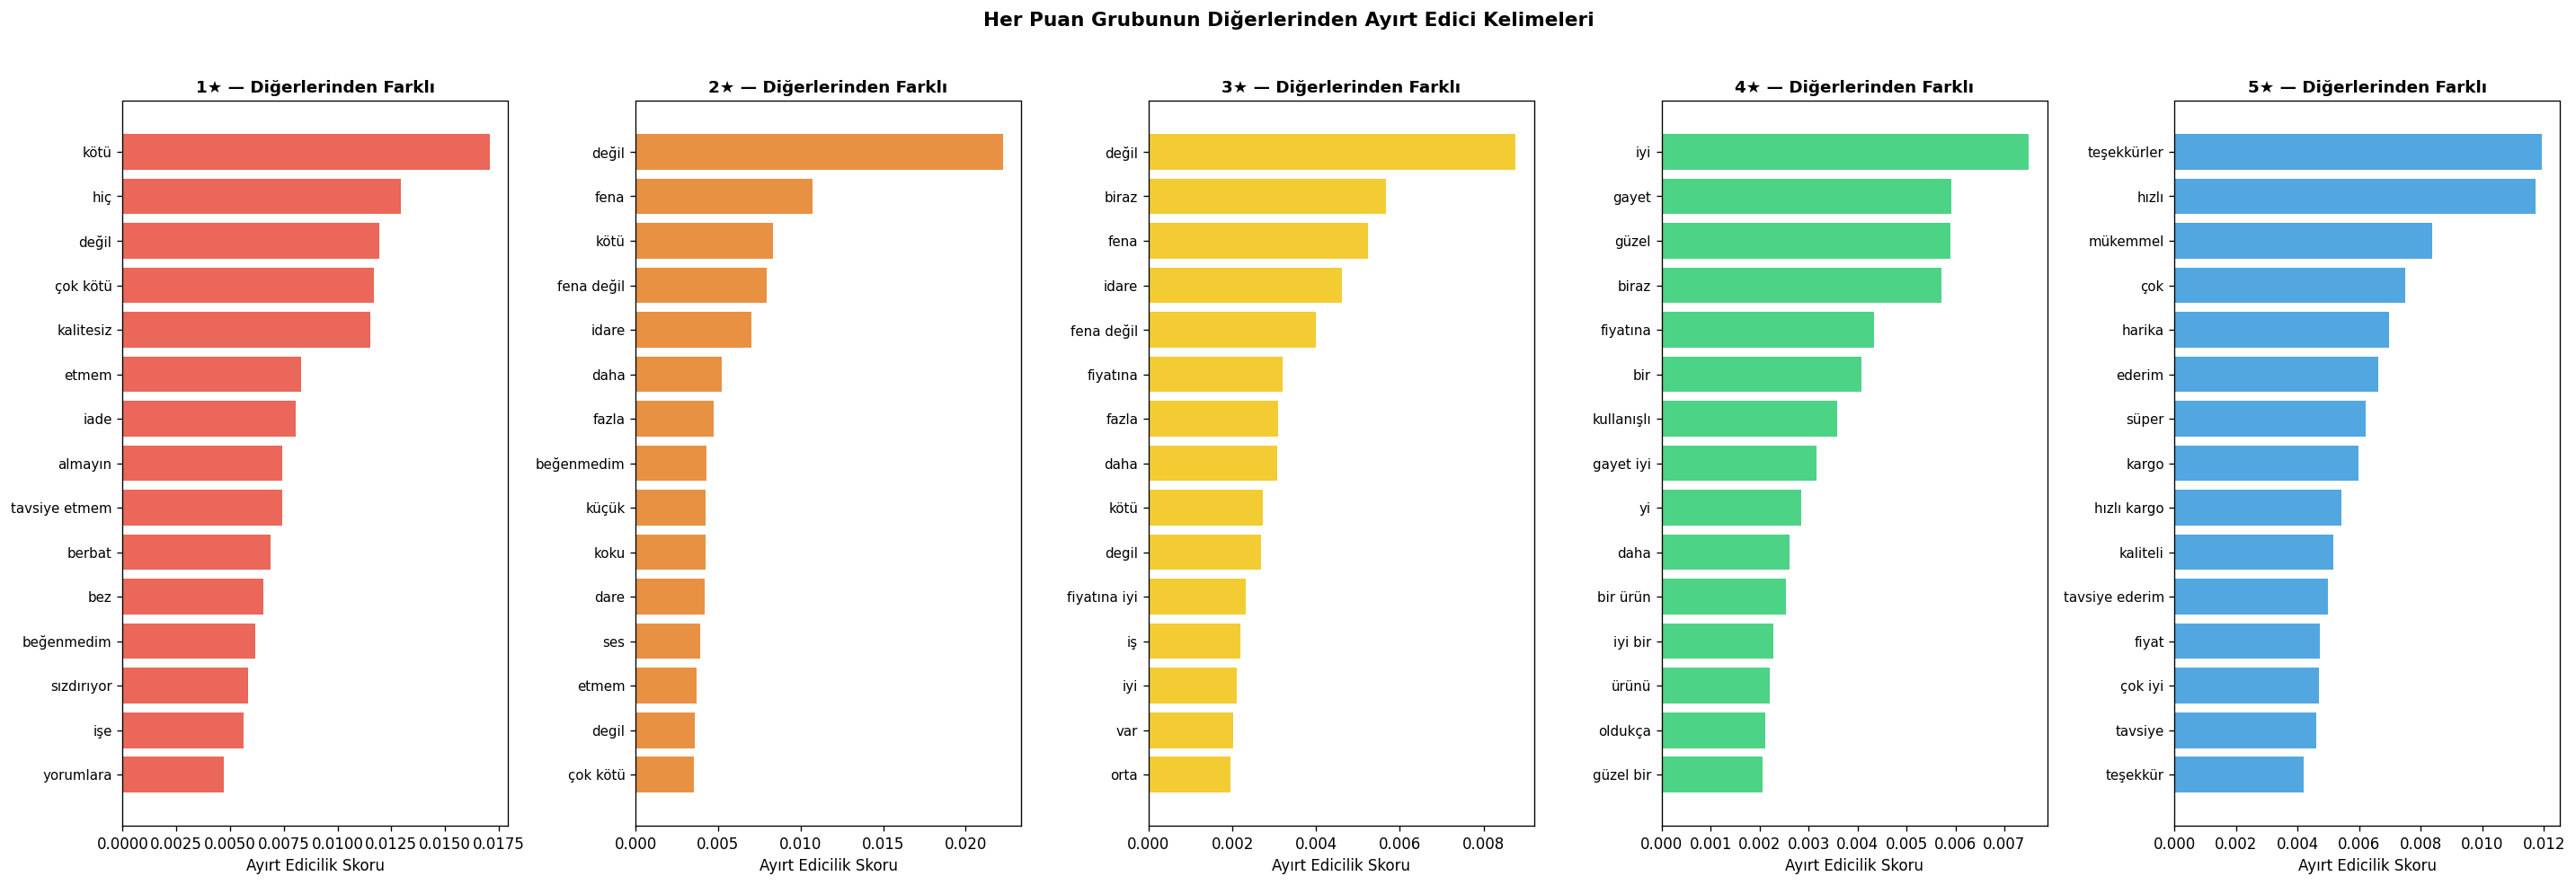


📊 Unigram vs Bigram Dağılımı:

Puan      Unigram     Bigram
────────────────────────────
1★             13          2
2★             13          2
3★             13          2
4★             11          4
5★             12          3

🔍 1★ vs 5★ En Ayırt Edici Kelimeler:

1★ (Negatif)                                     5★ (Pozitif)
──────────────────────────────────────────────────────────────
kötü                                              teşekkürler
hiç                                                     hızlı
değil                                                mükemmel
çok kötü                                                  çok
kalitesiz                                              harika
etmem                                                  ederim
iade                                                    süper
almayın                                                 kargo
tavsiye etmem                                     hızlı kargo
berbat                                     

In [8]:
# ============================================================
# HÜCRE 6A: TF-IDF & Kelime Analizi (Doğru Yaklaşım)
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── 6A.1 TF-IDF — Tüm Yorumlara Uygula ─────────────────────
# Her yorum ayrı doküman — 272k × 50k matris
print("⏳ TF-IDF hesaplanıyor...")

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # unigram + bigram
    min_df=10,             # en az 10 yorumda geçmeli
    max_features=50000,    # en bilgilendirici 50k özellik
    sublinear_tf=True      # log(TF) — tekrar etkisini dengele
)

tfidf_matrix = vectorizer.fit_transform(df['review_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"✅ Matris boyutu: {tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]:,} yorum × {tfidf_matrix.shape[1]:,} özellik")


# ── 6A.2 Ayırt Edici Kelime Fonksiyonu ──────────────────────
def get_distinctive_words(tfidf_matrix, df, rating, feature_names, n=15):
    """
    Bir puan grubunun DİĞER gruplara kıyasla
    en ayırt edici kelimelerini bulur.

    Yöntem:
      class_mean  = bu sınıftaki yorumların ortalama TF-IDF
      other_mean  = diğer sınıflardaki yorumların ortalama TF-IDF
      distinctiveness = class_mean - other_mean

    → Fark yüksekse kelime bu sınıfa özgü demektir
    """
    # Bu puana ait satırlar
    class_mask = (df['rating'] == rating).values
    other_mask = ~class_mask

    class_mean = tfidf_matrix[class_mask].mean(axis=0).A1
    other_mean = tfidf_matrix[other_mask].mean(axis=0).A1

    # Ayırt edicilik skoru
    distinctiveness = class_mean - other_mean

    top_idx   = distinctiveness.argsort()[::-1][:n]
    top_words = [
        (feature_names[i], distinctiveness[i], class_mean[i])
        for i in top_idx
    ]
    return top_words


# ── 6A.3 Tüm Puanlar İçin Hesapla ───────────────────────────
ratings = [1, 2, 3, 4, 5]
colors  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
top_n   = 15

all_top_words = {}
for rating in ratings:
    all_top_words[rating] = get_distinctive_words(
        tfidf_matrix, df, rating, feature_names, n=top_n
    )


# ── 6A.4 Görselleştirme ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 8))

for ax, rating, color in zip(axes, ratings, colors):
    words  = [w for w, d, c in all_top_words[rating]]
    scores = [d for w, d, c in all_top_words[rating]]

    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(f'{rating}★ — Diğerlerinden Farklı', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ayırt Edicilik Skoru')
    ax.tick_params(axis='y', labelsize=9)
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Her Puan Grubunun Diğerlerinden Ayırt Edici Kelimeleri',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ── 6A.5 Unigram vs Bigram Dağılımı ─────────────────────────
print("\n📊 Unigram vs Bigram Dağılımı:\n")
print(f"{'Puan':<6} {'Unigram':>10} {'Bigram':>10}")
print("─" * 28)
for rating in ratings:
    words    = [w for w, d, c in all_top_words[rating]]
    unigrams = sum(1 for w in words if len(w.split()) == 1)
    bigrams  = sum(1 for w in words if len(w.split()) == 2)
    print(f"{rating}★     {unigrams:>10} {bigrams:>10}")


# ── 6A.6 1★ vs 5★ Karşılaştırması ───────────────────────────
print("\n🔍 1★ vs 5★ En Ayırt Edici Kelimeler:\n")
print(f"{'1★ (Negatif)':<30} {'5★ (Pozitif)':>30}")
print("─" * 62)
for (w1, d1, c1), (w5, d5, c5) in zip(all_top_words[1], all_top_words[5]):
    print(f"{w1:<30} {w5:>30}")

## Adım 9 — Yüksek Skorlu Bigram Analizi
En yüksek ortalama TF-IDF değerine sahip ikili kelime grupları, puan kırılımıyla birlikte listelenir.

In [9]:
# ============================================================
# HÜCRE 6B: En Yüksek TF-IDF Skorlu Bigramlar → TXT
# ============================================================

# ── 6B.1 Tüm Bigramları Çıkar ────────────────────────────────
feature_names = vectorizer.get_feature_names_out()

# Sadece bigram olanları filtrele
bigram_mask    = np.array([len(f.split()) == 2 for f in feature_names])
bigram_names   = feature_names[bigram_mask]
bigram_matrix  = tfidf_matrix[:, bigram_mask]

print(f"✅ Toplam bigram sayısı: {len(bigram_names):,}")

# ── 6B.2 Ortalama TF-IDF Skoru Hesapla ──────────────────────
# Her bigram'ın tüm corpus'taki ortalama TF-IDF skoru
avg_scores = bigram_matrix.mean(axis=0).A1

# ── 6B.3 Her Puan İçin Ayrı Ortalama ────────────────────────
rating_avg_scores = {}
for rating in [1, 2, 3, 4, 5]:
    mask = (df['rating'] == rating).values
    rating_avg_scores[rating] = bigram_matrix[mask].mean(axis=0).A1

# ── 6B.4 Top 1000 Bigram → TXT'ye Kaydet ────────────────────
top_n = 2000
top_idx = avg_scores.argsort()[::-1][:top_n]

SAVE_PATH = '/content/drive/MyDrive/turkish_ecommerce_reviews/top_bigrams.txt'

with open(SAVE_PATH, 'w', encoding='utf-8') as f:
    f.write(f"Top {top_n} Bigram — Ortalama TF-IDF Skoru\n")
    f.write(f"Toplam bigram: {len(bigram_names):,}\n")
    f.write("=" * 70 + "\n")
    f.write(f"{'Sıra':<6} {'Bigram':<30} {'Genel':>8} "
            f"{'1★':>8} {'2★':>8} {'3★':>8} {'4★':>8} {'5★':>8}\n")
    f.write("=" * 70 + "\n")

    for rank, idx in enumerate(top_idx, 1):
        bigram = bigram_names[idx]
        genel  = avg_scores[idx]
        scores = [rating_avg_scores[r][idx] for r in [1,2,3,4,5]]
        f.write(f"{rank:<6} {bigram:<30} {genel:>8.5f} "
                f"{scores[0]:>8.5f} {scores[1]:>8.5f} "
                f"{scores[2]:>8.5f} {scores[3]:>8.5f} "
                f"{scores[4]:>8.5f}\n")

print(f"💾 Kaydedildi: {SAVE_PATH}")

# ── 6B.5 Önizleme ────────────────────────────────────────────
print(f"\n🔍 İlk 20 bigram:\n")
print(f"{'Sıra':<6} {'Bigram':<30} {'Genel':>8} "
      f"{'1★':>8} {'2★':>8} {'3★':>8} {'4★':>8} {'5★':>8}")
print("─" * 80)

for rank, idx in enumerate(top_idx[:20], 1):
    bigram = bigram_names[idx]
    genel  = avg_scores[idx]
    scores = [rating_avg_scores[r][idx] for r in [1,2,3,4,5]]
    print(f"{rank:<6} {bigram:<30} {genel:>8.5f} "
          f"{scores[0]:>8.5f} {scores[1]:>8.5f} "
          f"{scores[2]:>8.5f} {scores[3]:>8.5f} "
          f"{scores[4]:>8.5f}")

✅ Toplam bigram sayısı: 25,187
💾 Kaydedildi: /content/drive/MyDrive/turkish_ecommerce_reviews/top_bigrams.txt

🔍 İlk 20 bigram:

Sıra   Bigram                            Genel       1★       2★       3★       4★       5★
────────────────────────────────────────────────────────────────────────────────
1      tavsiye ederim                  0.01491  0.00125  0.00218  0.01016  0.01487  0.01683
2      bir ürün                        0.01286  0.00521  0.00711  0.01135  0.01482  0.01295
3      çok iyi                         0.01127  0.00142  0.00337  0.00580  0.01089  0.01308
4      çok güzel                       0.00796  0.00100  0.00217  0.00508  0.00682  0.00941
5      bu fiyata                       0.00653  0.00171  0.00347  0.00687  0.00687  0.00667
6      hızlı kargo                     0.00617  0.00047  0.00050  0.00237  0.00359  0.00826
7      güzel bir                       0.00602  0.00064  0.00205  0.00508  0.00761  0.00598
8      gayet güzel                     0.00553  0.0003

## Adım 10 — Modelleme Verisinin Hazırlanması
TF-IDF özellikleri ölçeklenmiş metadata ile birleştirilir ve veri, eğitim/test olarak ayrılır.

In [10]:
# ============================================================
# HÜCRE 7: Veri Hazırlama
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import scipy.sparse as sp
import numpy as np

# ── 7.1 Hedef Değişken ──────────────────────────────────────
y = df['rating'].values
print(f"📊 Sınıf Dağılımı:")
for rating in [1, 2, 3, 4, 5]:
    count = (y == rating).sum()
    pct   = count / len(y) * 100
    print(f"  {rating}★ → {count:>6,} yorum ({pct:.1f}%)")

# ── 7.2 Metadata Normalize Et ───────────────────────────────
META_COLS = ['review_length', 'exclamation_count',
             'question_count', 'upper_ratio']

scaler          = StandardScaler()
metadata_scaled = scaler.fit_transform(df[META_COLS])
metadata_sparse = sp.csr_matrix(metadata_scaled)

print(f"\n📐 Metadata normalize edildi:")
print(f"  Özellikler : {META_COLS}")
print(f"  Boyut      : {metadata_sparse.shape}")
print(f"\n  Normalize öncesi (review_length):")
print(f"    min={df['review_length'].min()}, "
      f"max={df['review_length'].max()}, "
      f"mean={df['review_length'].mean():.1f}")
print(f"  Normalize sonrası (review_length):")
print(f"    min={metadata_scaled[:,0].min():.2f}, "
      f"max={metadata_scaled[:,0].max():.2f}, "
      f"mean={metadata_scaled[:,0].mean():.2f}")

# ── 7.3 TF-IDF + Metadata Birleştir ─────────────────────────
X = hstack([tfidf_matrix, metadata_sparse])
print(f"\n📐 Matris Boyutları:")
print(f"  TF-IDF         : {tfidf_matrix.shape}")
print(f"  Metadata       : {metadata_sparse.shape}")
print(f"  Birleşik (X)   : {X.shape}")

# ── 7.4 Train / Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Train/Test Split:")
print(f"  Train : {X_train.shape[0]:>6,} yorum (%80)")
print(f"  Test  : {X_test.shape[0]:>6,} yorum (%20)")

print(f"\n📊 Train sınıf dağılımı (stratify kontrolü):")
for rating in [1, 2, 3, 4, 5]:
    count = (y_train == rating).sum()
    pct   = count / len(y_train) * 100
    print(f"  {rating}★ → {count:>6,} ({pct:.1f}%)")

📊 Sınıf Dağılımı:
  1★ →  7,225 yorum (2.7%)
  2★ →  6,447 yorum (2.4%)
  3★ → 28,702 yorum (10.5%)
  4★ → 62,371 yorum (22.9%)
  5★ → 167,358 yorum (61.5%)

📐 Metadata normalize edildi:
  Özellikler : ['review_length', 'exclamation_count', 'question_count', 'upper_ratio']
  Boyut      : (272103, 4)

  Normalize öncesi (review_length):
    min=3, max=2057, mean=165.9
  Normalize sonrası (review_length):
    min=-1.01, max=11.70, mean=0.00

📐 Matris Boyutları:
  TF-IDF         : (272103, 50000)
  Metadata       : (272103, 4)
  Birleşik (X)   : (272103, 50004)

✅ Train/Test Split:
  Train : 217,682 yorum (%80)
  Test  : 54,421 yorum (%20)

📊 Train sınıf dağılımı (stratify kontrolü):
  1★ →  5,780 (2.7%)
  2★ →  5,158 (2.4%)
  3★ → 22,961 (10.5%)
  4★ → 49,897 (22.9%)
  5★ → 133,886 (61.5%)


## Adım 11 — Model Eğitimi (Logistic Regression)
Sınıf dengesizliğini telafi etmek için `class_weight='balanced'` ile Logistic Regression eğitilir. Model; accuracy, MAE ve confusion matrix ile değerlendirilir. MAE ve confusion matrix, komşu yıldızlar arasındaki hatayı da görünür kılar.

⏳ Model eğitimi başlıyor...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


max_iter reached after 311 seconds

✅ Eğitim tamamlandı! (311.4 sn)

📊 Model Performansı:
  Accuracy : 0.5421  (54.21%)
  MAE      : 0.6572  (ortalama 0.66 yıldız hata)

📋 Classification Report:
              precision    recall  f1-score   support

          1★       0.36      0.68      0.47      1445
          2★       0.17      0.43      0.25      1289
          3★       0.24      0.35      0.28      5741
          4★       0.37      0.43      0.40     12474
          5★       0.81      0.61      0.70     33472

    accuracy                           0.54     54421
   macro avg       0.39      0.50      0.42     54421
weighted avg       0.62      0.54      0.57     54421



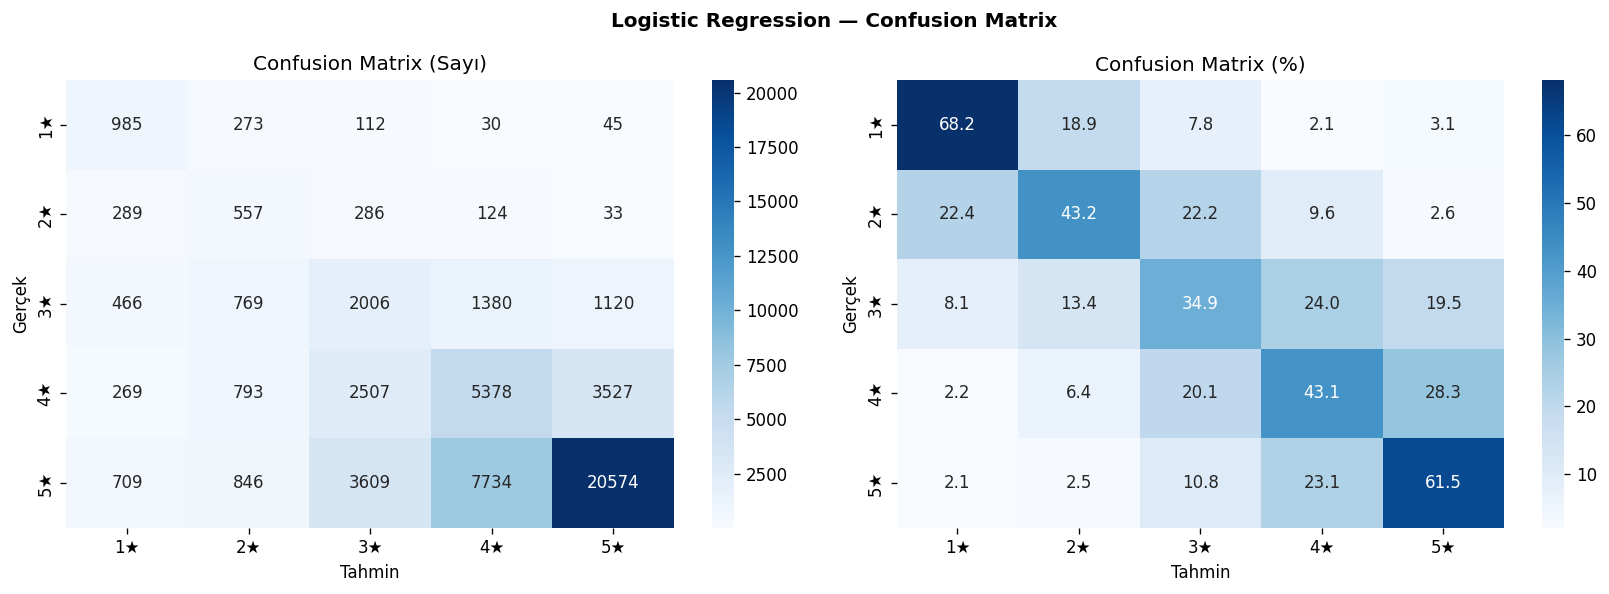

In [11]:
# ============================================================
# HÜCRE 8: Model Eğitimi
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_absolute_error)
import threading
import time
import sys

# ── 8.1 Model Tanımla ────────────────────────────────────────
lr_model = LogisticRegression(
    class_weight='balanced',  # dengesiz veri için (1★ %2.7)
    max_iter=1000,            # maksimum iterasyon
    random_state=42,
    C=1.0,                    # regularization
    solver='saga',            # sparse matris + multiclass için
    n_jobs=-1,                # tüm CPU'ları kullan
    verbose=1                 # iterasyon ilerleyişini göster
)

# ── 8.2 Eğit ────────────────────────────────────────────────
print("⏳ Model eğitimi başlıyor...\n")
start = time.time()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start
print(f"\n✅ Eğitim tamamlandı! ({lr_time:.1f} sn)\n")

# ── 8.3 Tahmin ───────────────────────────────────────────────
y_pred = lr_model.predict(X_test)

# ── 8.4 Metrikler ────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"📊 Model Performansı:")
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  MAE      : {mae:.4f}  (ortalama {mae:.2f} yıldız hata)")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['1★','2★','3★','4★','5★']))

# ── 8.5 Confusion Matrix ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1★','2★','3★','4★','5★'],
            yticklabels=['1★','2★','3★','4★','5★'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Sayı)')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['1★','2★','3★','4★','5★'],
            yticklabels=['1★','2★','3★','4★','5★'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

plt.suptitle('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## Adım 12 — Özellik Önemi ve Yorumlanabilirlik
Model katsayıları kullanılarak her sınıf için en etkili kelimeler belirlenir; böylece modelin kararları yorumlanabilir hâle gelir.

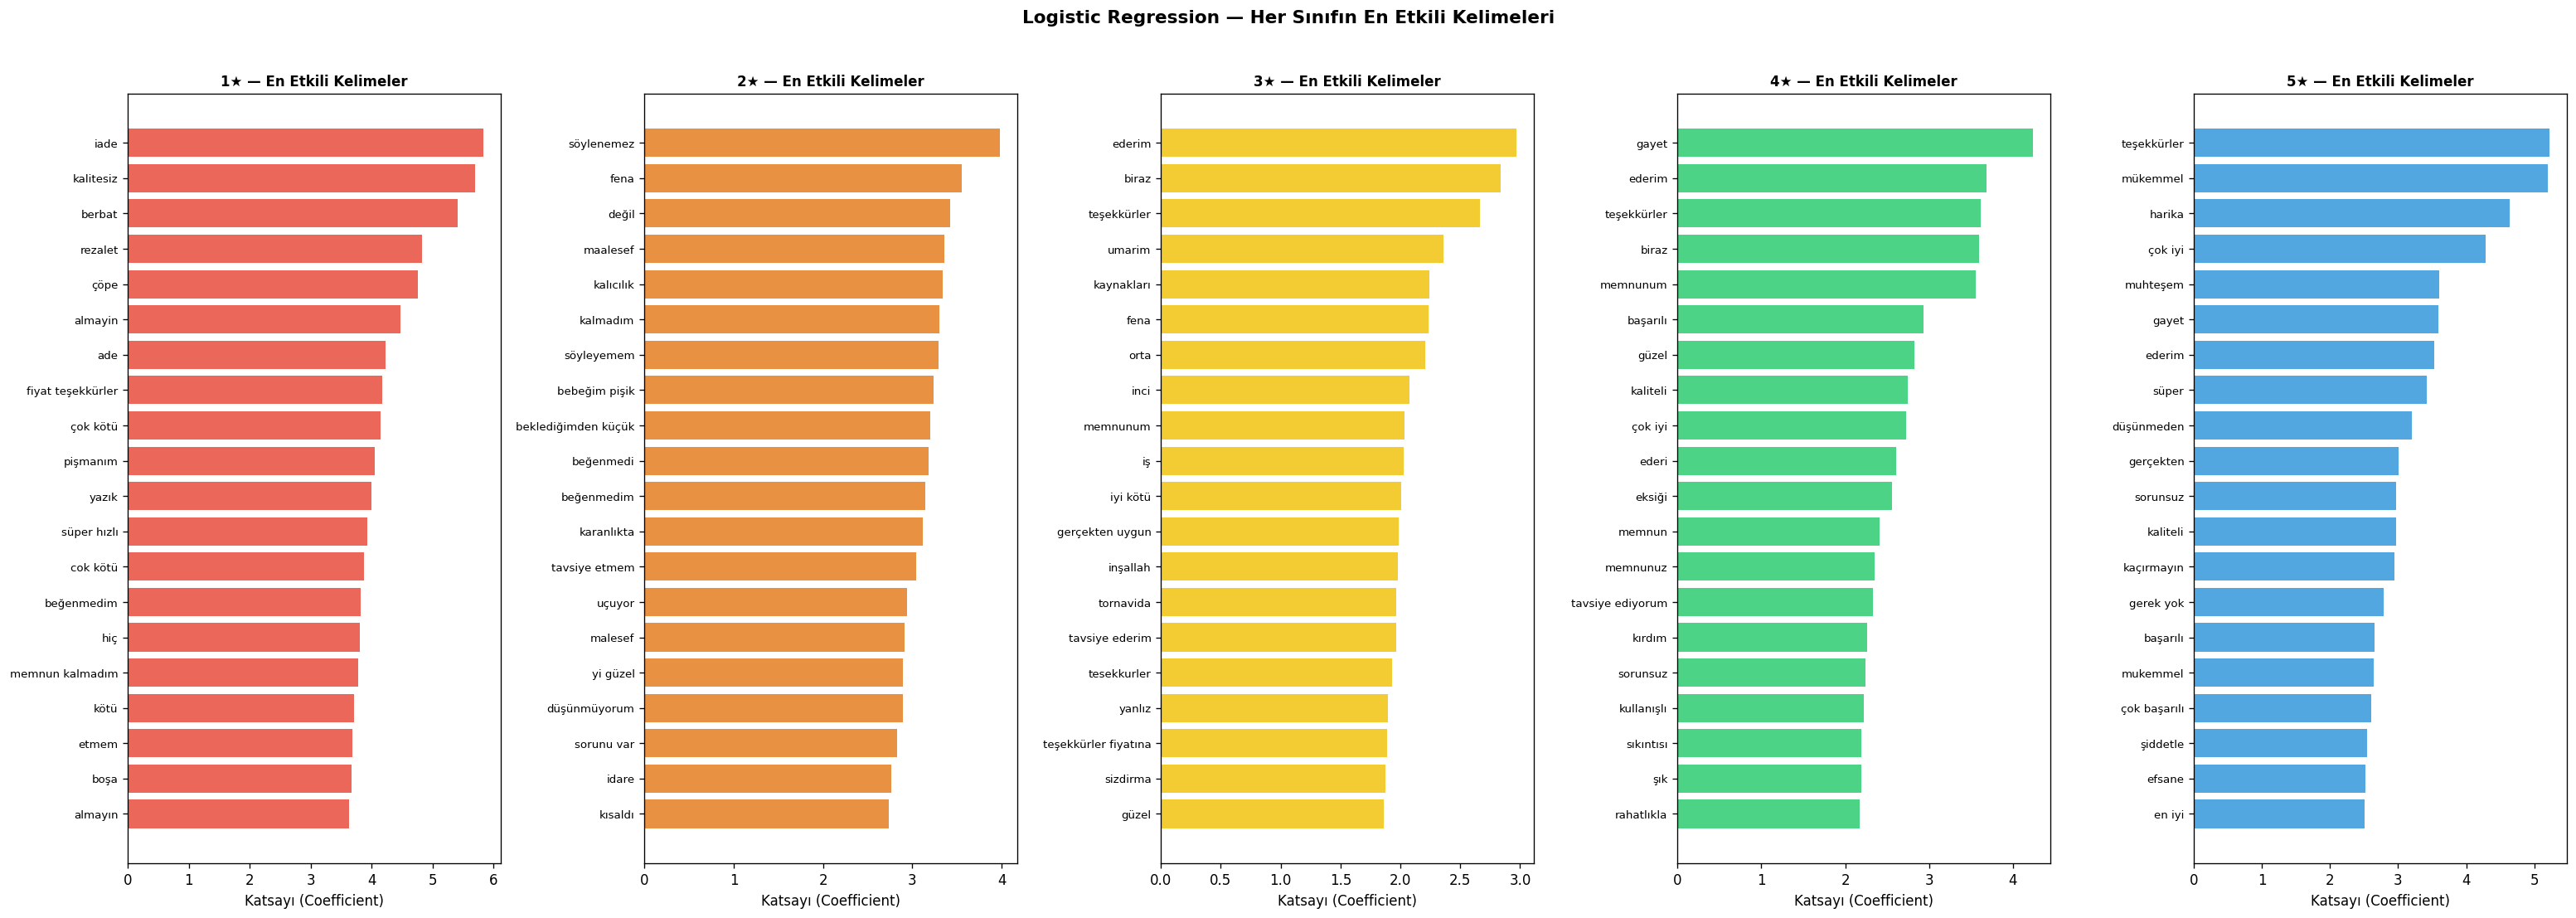

🔍 1★ vs 5★ En Etkili Kelimeler:

1★ Kelime                  Katsayı   5★ Kelime                  Katsayı
──────────────────────────────────────────────────────────────────────
iade                        5.8328   teşekkürler                 5.2181
kalitesiz                   5.7077   mükemmel                    5.1982
berbat                      5.4141   harika                      4.6387
rezalet                     4.8283   çok iyi                     4.2804
çöpe                        4.7668   muhteşem                    3.6051
almayin                     4.4754   gayet                       3.5961
ade                         4.2267   ederim                      3.5355
fiyat teşekkürler           4.1800   süper                       3.4232
çok kötü                    4.1540   düşünmeden                  3.2043
pişmanım                    4.0554   gerçekten                   3.0042
yazık                       3.9946   sorunsuz                    2.9654
süper hızlı                 3.93

In [12]:
# ============================================================
# HÜCRE 9: Feature Importance
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── 9.1 Katsayıları Al ───────────────────────────────────────
# lr_model.coef_ → shape: (5, 50004)
# Her satır bir sınıf, her sütun bir özellik
# TF-IDF adları + metadata adları -> coef sütunlarıyla HİZALI olsun
# (aksi halde en etkili index metadata'ya denk gelince IndexError olur)
feature_names = np.array(list(vectorizer.get_feature_names_out()) + META_COLS)
coef          = lr_model.coef_  # (5, n_tfidf + 4_metadata)

ratings       = [1, 2, 3, 4, 5]
colors        = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db']
top_n         = 20

# ── 9.2 Her Sınıf İçin En Etkili Kelimeler ──────────────────
fig, axes = plt.subplots(1, 5, figsize=(26, 9))

all_top = {}

for ax, rating, color in zip(axes, ratings, colors):
    idx     = rating - 1          # 1★ → index 0
    coefs   = coef[idx]           # bu sınıfın katsayıları

    # En yüksek pozitif katsayılar → bu sınıfı en çok artıranlar
    top_idx   = coefs.argsort()[::-1][:top_n]
    top_words = feature_names[top_idx]
    top_vals  = coefs[top_idx]

    all_top[rating] = list(zip(top_words, top_vals))

    ax.barh(top_words[::-1], top_vals[::-1],
            color=color, alpha=0.85)
    ax.set_title(f'{rating}★ — En Etkili Kelimeler',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Katsayı (Coefficient)')
    ax.tick_params(axis='y', labelsize=8)
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Logistic Regression — Her Sınıfın En Etkili Kelimeleri',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ── 9.3 1★ vs 5★ Detaylı Karşılaştırma ──────────────────────
print("🔍 1★ vs 5★ En Etkili Kelimeler:\n")
print(f"{'1★ Kelime':<25} {'Katsayı':>8}   "
      f"{'5★ Kelime':<25} {'Katsayı':>8}")
print("─" * 70)

for (w1, c1), (w5, c5) in zip(all_top[1], all_top[5]):
    print(f"{w1:<25} {c1:>8.4f}   {w5:<25} {c5:>8.4f}")


# ── 9.4 Bir Kelimenin Tüm Sınıflardaki Etkisi ───────────────
def word_impact(word):
    """Bir kelimenin tüm puanlar üzerindeki etkisini gösterir."""
    if word not in feature_names:
        print(f"'{word}' vektörde bulunamadı.")
        return

    word_idx = np.where(feature_names == word)[0][0]
    print(f"\n📊 '{word}' kelimesinin sınıf katsayıları:")
    print(f"  {'Puan':<6} {'Katsayı':>10} {'Etki'}")
    print("  " + "─" * 35)
    for i, rating in enumerate(ratings):
        c = coef[i][word_idx]
        bar = '█' * int(abs(c) * 20)
        direction = '▲ artırıyor' if c > 0 else '▼ azaltıyor'
        print(f"  {rating}★     {c:>10.4f}  {direction} {bar}")

# Örnek kullanım
word_impact('berbat')
word_impact('mükemmel')
word_impact('kalitesiz')

# Bölüm 2 — Sızıntısız Değerlendirme ve Veri-Odaklı Özellik Seçimi

Bu bölümde değerlendirme kurulumu metodolojik olarak güçlendirilir ve kontrollü bir özellik seçimi (ablation) deneyi yapılır:

1. **Tekrarların ayıklanması (deduplication):** Aynı yorumun hem eğitim hem test kümesinde yer almasından kaynaklanan veri sızıntısı engellenir.
2. **Yalnızca eğitime fit:** TF-IDF vektörleştirici yalnızca eğitim kümesine fit edilir.
3. **Veri-odaklı özellik seçimi:** Frekansı yüksek ancak sınıfları ayırt etmeyen birli ve ikili n-gram'lar sözlükten çıkarılır.

Stopword'ler tek kelime düzeyinde çalıştığından ikili n-gram'lar bu yöntemle çıkarılamaz; bu nedenle seçim, TF-IDF sözlüğünden ilgili terimlerin çıkarılmasıyla özellik düzeyinde uygulanır.

## 2.1 — Veri Hazırlığı (deduplication + sızıntısız ayrım)

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import scipy.sparse as sp

# 1) DEDUP: aynı temizlenmiş yorumu bir kez tut -> leakage'ı kapat
before = len(df)
df_u = df.drop_duplicates(subset=['review_clean']).reset_index(drop=True)
print(f"Dedup: {before:,} -> {len(df_u):,} ({before-len(df_u):,} tekrar atildi)")

y = df_u['rating'].astype(int).values
txt = df_u['review_clean'].values

# 2) Önce böl, SONRA sadece train'e fit (train-only)
idx = np.arange(len(df_u))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
y_tr, y_te = y[idx_tr], y[idx_te]

# 3) Metadata (sadece train'e fit edilen scaler)
META_COLS = ['review_length', 'exclamation_count', 'question_count', 'upper_ratio']
scaler = StandardScaler()
meta_tr = sp.csr_matrix(scaler.fit_transform(df_u.iloc[idx_tr][META_COLS]))
meta_te = sp.csr_matrix(scaler.transform(df_u.iloc[idx_te][META_COLS]))
print("Train:", len(idx_tr), " Test:", len(idx_te))

Dedup: 272,103 -> 233,812 (38,291 tekrar atildi)
Train: 187049  Test: 46763


## 2.2 — v1 (Referans Model): TF-IDF Yalnızca Eğitime Fit

In [14]:
vec1 = TfidfVectorizer(ngram_range=(1, 2), min_df=10, max_features=50000, sublinear_tf=True)
Xtr1 = vec1.fit_transform(txt[idx_tr])   # <-- sadece train
Xte1 = vec1.transform(txt[idx_te])
X1_tr = hstack([Xtr1, meta_tr]).tocsr()
X1_te = hstack([Xte1, meta_te]).tocsr()
print("v1 ozellik sayisi:", X1_tr.shape[1])

v1 ozellik sayisi: 45677


## 2.3 — Düşük Sinyalli Özelliklerin Belirlenmesi (birli + ikili n-gram)
Ölçüt: doküman frekansı yüksek ve sınıflar arası göreli ayırt ediciliği düşük olan terimler. Frekans eşiği birli ve ikili n-gram'lar için ayrı hesaplanır. Olumsuzluk ve duygu bildiren kelimeler korunur.

In [15]:
fn = vec1.get_feature_names_out()
doc_freq = np.asarray((Xtr1 > 0).sum(axis=0)).ravel()           # kac yorumda geciyor

# sinif-bazli ortalama TF-IDF -> goreli ayirt edicilik (dusuk = stopword-benzeri)
class_means = np.vstack([np.asarray(Xtr1[y_tr == r].mean(axis=0)).ravel()
                         for r in [1, 2, 3, 4, 5]])
discrim_rel = (class_means.max(0) - class_means.min(0)) / (class_means.mean(0) + 1e-9)

is_uni = np.array([' ' not in w for w in fn])

# frekans esigi uni/bigram icin AYRI (bigram'lar da yakalansin)
freq_thr_uni = np.percentile(doc_freq[is_uni],  92)
freq_thr_bi  = np.percentile(doc_freq[~is_uni], 92)
high_freq = (is_uni & (doc_freq >= freq_thr_uni)) | (~is_uni & (doc_freq >= freq_thr_bi))

disc_thr = np.percentile(discrim_rel, 30)        # alt %30 ayirt edicilik

# olumsuzluk/duygu kelimelerini KORU
KORU = {'değil', 'yok', 'ama', 'fakat', 'ancak', 'rağmen', 'yine',
        'çok', 'hiç', 'az', 'fazla', 'daha', 'en', 'gayet'}
protect = np.array([w in KORU for w in fn])

drop_mask = high_freq & (discrim_rel <= disc_thr) & (~protect)
drop_features = set(fn[drop_mask])

n_uni = sum(' ' not in w for w in drop_features)
n_bi  = sum(' ' in w for w in drop_features)
print(f"Budanan ozellik: {len(drop_features)}  (unigram {n_uni}, bigram {n_bi})")
print("Ornek unigram:", [w for w in fn[drop_mask] if ' ' not in w][:15])
print("Ornek bigram :", [w for w in fn[drop_mask] if ' ' in w][:15])

Budanan ozellik: 2872  (unigram 1680, bigram 1192)
Ornek unigram: ['acayip', 'acı', 'adaptör', 'adaptörü', 'adı', 'adım', 'ailesi', 'aklıma', 'aksam', 'aksine', 'aktarım', 'aktif', 'akıcı', 'akıllı', 'al']
Ornek bigram : ['aktarım hızı', 'akıcı bir', 'alabi li', 'alabileceğiniz bir', 'alabileceğiniz en', 'alacaklara tavsiye', 'alan pişman', 'aldim çok', 'aldım aynı', 'aldım bir', 'aldım bu', 'aldım cok', 'aldım daha', 'aldım en', 'aldım fiyat']


## 2.4 — v2 (Budanmış Sözlük): Düşük Sinyalli Özellikler Çıkarılmış

In [16]:
keep_vocab = [w for w in fn if w not in drop_features]
# vocabulary verildiginde min_df/max_features yok sayilir; IDF train'e fit edilir
vec2 = TfidfVectorizer(ngram_range=(1, 2), vocabulary=keep_vocab, sublinear_tf=True)
Xtr2 = vec2.fit_transform(txt[idx_tr])
Xte2 = vec2.transform(txt[idx_te])
X2_tr = hstack([Xtr2, meta_tr]).tocsr()
X2_te = hstack([Xte2, meta_te]).tocsr()
print(f"v2 ozellik: {X2_tr.shape[1]}  (v1: {X1_tr.shape[1]})")

v2 ozellik: 42805  (v1: 45677)


## 2.5 — Karşılaştırma: Aynı Ayrım, Aynı Model (Logistic Regression)
v1 ve v2, yalnızca özellik kümesi farkıyla; aynı eğitim/test ayrımı ve aynı model kullanılarak karşılaştırılır.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

def egit_degerlendir(Xtr, Xte, etiket):
    clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0,
                             solver='saga', n_jobs=-1)
    clf.fit(Xtr, y_tr)
    pred = clf.predict(Xte)
    acc  = accuracy_score(y_te, pred)
    off1 = np.mean(np.abs(y_te - pred) <= 1)
    mae  = mean_absolute_error(y_te, pred)
    mf1  = f1_score(y_te, pred, average='macro')
    print(f"{etiket:<30} acc={acc*100:5.2f}  ±1={off1*100:5.2f}  MAE={mae:.3f}  macroF1={mf1:.3f}")
    return acc, off1, mae, mf1

print("Egitiliyor (saga, birkac dk)...\n")
r1 = egit_degerlendir(X1_tr, X1_te, "v1 (duzeltilmis, tum ozellik)")
r2 = egit_degerlendir(X2_tr, X2_te, "v2 (dusuk-sinyal budanmis)")
print(f"\nFark (v2 - v1): accuracy {(r2[0]-r1[0])*100:+.2f} puan, "
      f"macro-F1 {(r2[3]-r1[3]):+.3f}")

Egitiliyor (saga, birkac dk)...

v1 (duzeltilmis, tum ozellik)  acc=51.17  ±1=83.45  MAE=0.709  macroF1=0.382
v2 (dusuk-sinyal budanmis)     acc=48.65  ±1=82.16  MAE=0.748  macroF1=0.355

Fark (v2 - v1): accuracy -2.52 puan, macro-F1 -0.027


## 2.6 — Bulgular
- Özellik budama (v2), referans modele (v1) göre doğruluğu düşürmüştür (accuracy −2.5 puan, macro-F1 −0.027). Bu sonuç, TF-IDF'in IDF bileşeninin yüksek frekanslı kelimeleri zaten ağırlıklandırdığını ve ek budamanın bilgi kaybına yol açtığını göstermektedir.
- Tekrarların ayıklanması ve yalnızca eğitime fit edilen vektörleştirme ile elde edilen metrikler, veri sızıntısı içermeyen daha güvenilir bir değerlendirmeyi yansıtır.

# Bölüm 3 — Ek Klasik Metin Madenciliği Bileşenleri
Kök bulma (stemming), Naive Bayes ile model karşılaştırması ve kelime bulutu görselleştirmesi ile çalışma tamamlanır. Bu bölüm, Bölüm 2'de oluşturulan veri ve değişkenler üzerine kuruludur.

## 3.1 — Kök Bulma (Stemming)
Kelimeler köküne indirgenir ('geldi', 'gelmiş', 'geliyor' → 'gel'). Türkçe eklemeli bir dil olduğundan aynı kökün çekimleri ayrı özelliklere dağılır; kök bulma bu özellikleri birleştirir. Java bağımlılığı olmayan snowballstemmer kullanılır. Snowball Türkçe algoritması agresif bir kök bulma uygular ve kimi kelimelerde anlam kaybına yol açabilir (ör. 'iyi' → 'i'); etkisi karşılaştırma ile ölçülür.

In [18]:
!pip install -q snowballstemmer
import snowballstemmer
from itertools import chain

stemmer = snowballstemmer.stemmer('turkish')

# Hız için benzersiz kelimeleri bir kez stemle (cache)
all_words = set(chain.from_iterable(t.split() for t in df_u['review_clean']))
stem_map = dict(zip(all_words, stemmer.stemWords(list(all_words))))
df_u['review_stem'] = df_u['review_clean'].map(lambda t: ' '.join(stem_map[w] for w in t.split()))

print(f"Benzersiz kelime: {len(all_words):,}")
for i in range(2):
    print(" ham :", df_u['review_clean'].iloc[i][:80])
    print(" stem:", df_u['review_stem'].iloc[i][:80])


Benzersiz kelime: 311,004
 ham : tık demedi
 stem: tık demedi
 ham : kullanıyorum müthiş
 stem: kullanıyor müthiş


### Karşılaştırma
Kök bulunmuş metinle aynı pipeline (yalnızca eğitime fit edilen TF-IDF + Logistic Regression) kurulur ve kök bulunmamış referans model (v1) ile karşılaştırılır.

In [19]:
txt_stem = df_u['review_stem'].values
vec_s = TfidfVectorizer(ngram_range=(1, 2), min_df=10, max_features=50000, sublinear_tf=True)
Xtr_s = vec_s.fit_transform(txt_stem[idx_tr])
Xte_s = vec_s.transform(txt_stem[idx_te])
Xs_tr = hstack([Xtr_s, meta_tr]).tocsr()
Xs_te = hstack([Xte_s, meta_te]).tocsr()
print("stem ozellik:", Xs_tr.shape[1], " (v1:", X1_tr.shape[1], ")\n")

rs = egit_degerlendir(Xs_tr, Xs_te, "stem'li (LogReg)")
print(f"Fark (stem - v1): accuracy {(rs[0]-r1[0])*100:+.2f} puan, macro-F1 {(rs[3]-r1[3]):+.3f}")


stem ozellik: 42495  (v1: 45677 )

stem'li (LogReg)               acc=50.69  ±1=82.84  MAE=0.725  macroF1=0.376
Fark (stem - v1): accuracy -0.48 puan, macro-F1 -0.006


## 3.2 — Model Karşılaştırması: Naive Bayes ve Logistic Regression
MultinomialNB, metin sınıflandırmada yaygın kullanılan olasılıksal bir temel algoritmadır ve TF-IDF özellikleri üzerinde çalışır. Naive Bayes negatif değer kabul etmediğinden, karşılaştırmada (ölçeklenmiş metadata değil) yalnızca TF-IDF özellikleri kullanılır.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

def kiyas(clf, lbl):
    clf.fit(Xtr1, y_tr)
    p = clf.predict(Xte1)
    print(f"{lbl:<24} acc={accuracy_score(y_te,p)*100:5.2f}  "
          f"±1={np.mean(np.abs(y_te-p)<=1)*100:5.2f}  "
          f"MAE={mean_absolute_error(y_te,p):.3f}  "
          f"macroF1={f1_score(y_te,p,average='macro'):.3f}")

print("Sadece TF-IDF ozellikleri uzerinde:\n")
kiyas(MultinomialNB(), "Naive Bayes")
kiyas(LogisticRegression(class_weight='balanced', max_iter=1000,
                         solver='saga', n_jobs=-1), "Logistic Regression")


Sadece TF-IDF ozellikleri uzerinde:

Naive Bayes              acc=62.19  ±1=87.29  MAE=0.557  macroF1=0.242
Logistic Regression      acc=56.94  ±1=88.33  MAE=0.593  macroF1=0.375


## 3.3 — Kelime Bulutu (Görselleştirme)
1★ ve 5★ yorumlarda öne çıkan kelimeler, frekansa dayalı kelime bulutu ile görselleştirilerek karşılaştırılır.

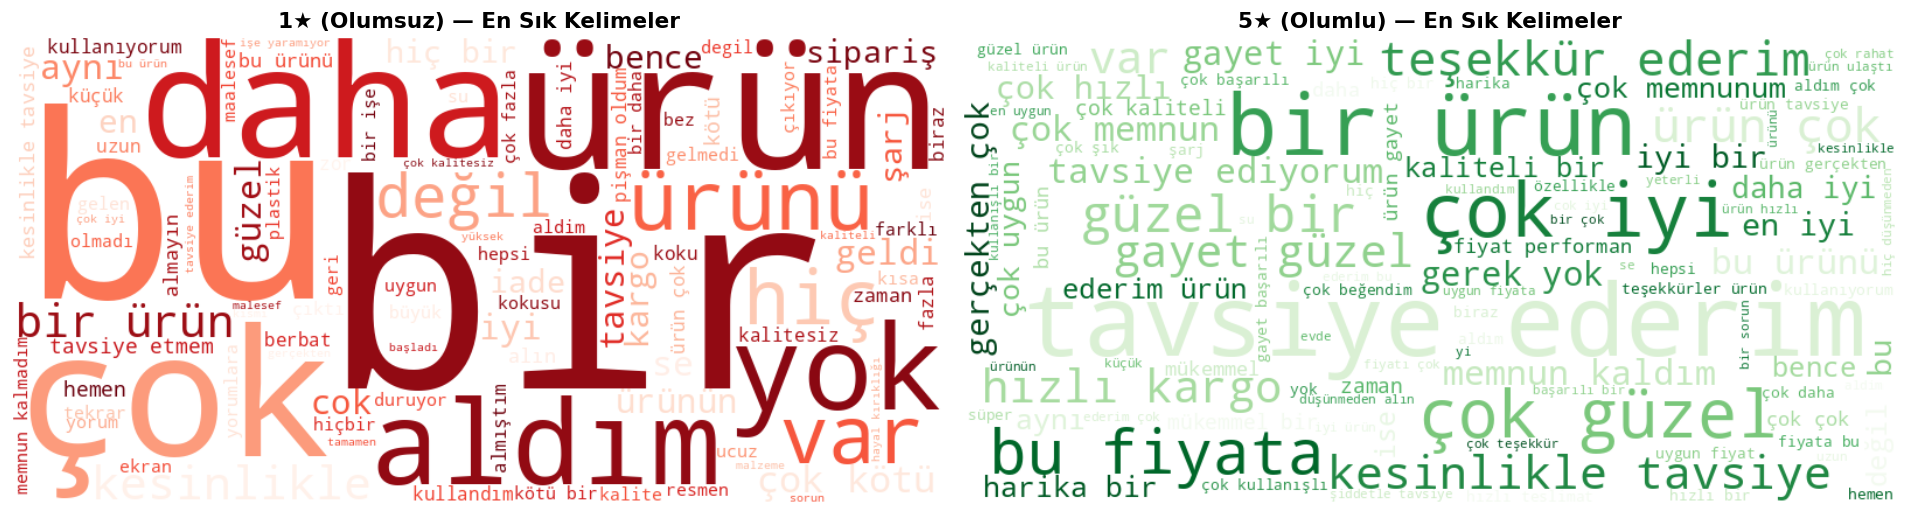

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, r, baslik, cmap in zip(axes, [1, 5],
                               ['1★ (Olumsuz)', '5★ (Olumlu)'], ['Reds', 'Greens']):
    metin = ' '.join(df_u[df_u['rating'] == r]['review_clean'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap=cmap).generate(metin)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{baslik} — En Sık Kelimeler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.4 — Genel Değerlendirme

Çalışmada keşifsel veri analizi, TF-IDF tabanlı özellik çıkarımı, Logistic Regression ile 1–5 yıldız sınıflandırması ve model yorumlanabilirliği uygulanmış; ardından sızıntısız bir değerlendirme kurulumu ile üç karşılaştırma gerçekleştirilmiştir.

| Karşılaştırma | Sonuç |
|---|---|
| Referans (v1: dedup + yalnızca eğitime fit) | accuracy 51.2%, MAE 0.71, macro-F1 0.38 |
| Veri-odaklı özellik budama (v2) | accuracy 48.7% (v1'e göre −2.5 puan) |
| Kök bulma (stemming) | accuracy 50.7% (v1'e göre −0.5 puan) |
| Naive Bayes (TF-IDF) | accuracy 62.2%, macro-F1 0.24 |
| Logistic Regression (TF-IDF) | accuracy 56.9%, macro-F1 0.38 |

**Çıkarımlar:**
- Komşu yıldızlar (özellikle 4★–5★) metinsel olarak birbirine yakın olduğundan, exact accuracy yanında ±1 accuracy ve MAE daha bilgilendiricidir.
- Özellik budama ve kök bulma bu görevde doğruluğu artırmamıştır; TF-IDF temsilinin mevcut hâli yeterince bilgilidir.
- Naive Bayes daha yüksek genel doğruluk verirken çoğunluk sınıfına eğilimlidir; sınıf ağırlıklı Logistic Regression azınlık sınıflarında daha dengeli sonuç (daha yüksek macro-F1) üretir.
- Sınıf dengesizliği nedeniyle accuracy tek başına yeterli değildir; macro-F1 ile birlikte değerlendirilmelidir.

**Sınırlılıklar ve gelecek çalışma:** Etiket gürültüsü (kullanıcıların birbirine yakın yıldızları öznel biçimde vermesi) ulaşılabilir doğruluğa bir üst sınır koymaktadır. Bağlamı ve olumsuzluğu doğrudan modelleyebilen Transformer tabanlı bir yaklaşım (ör. BERTurk ince-ayarı) gelecek çalışma olarak değerlendirilebilir.